# Exploratory Data Analysis on Amazon Sales Dataset

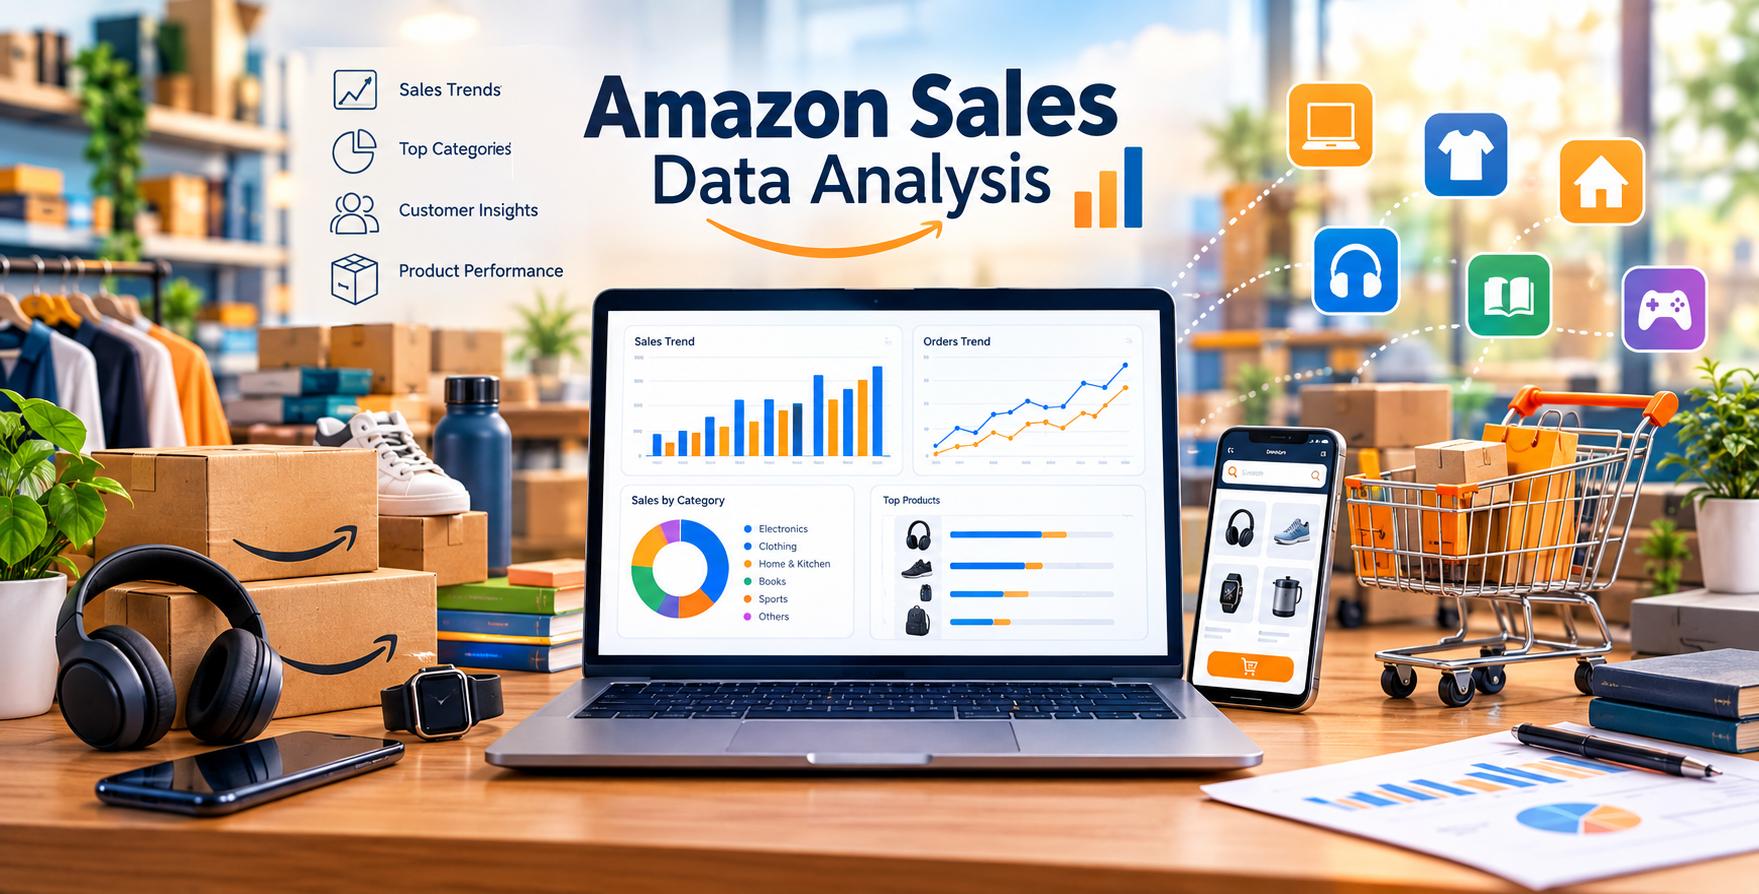

In [135]:


from IPython.display import Image
Image(filename= r"C:\Users\Priyanka\Downloads\ChatGPT Image Oct 2, 2026, 02_15_07 AM.png")


# Dataset Overview

### Amazon company wants to know about the ordering quantity relative to place, brand, category,customer and revenue generated by each product. For that they have shared a dataset which has following information:
* The dataset contains customer name, customer id and the name of city and state of order.
* The ordering quantity, product brand, product id, category and unit price.
* The order id, order date and order status.
* Based on this analysis,they want to design a model that estimates customer purchase amounts across different products.

## By the end of this project we will get insights about leading products in terms of revenue, order and region and many more things.


In [1]:
import numpy as np
import pandas as pd
import seaborn as srs
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [31]:
df = pd.read_csv(r"C:\Users\Priyanka\Downloads\Amazon-selected-columns3.csv.crswap")
df

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,OrderStatus,City,State
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,Delivered,Washington,DC
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,Delivered,Fort Worth,TX
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,Delivered,Austin,TX
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,Delivered,Charlotte,NC
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,Cancelled,San Antonio,TX
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99917,ORD0099918,2023-11-07,CUST013838,Karan Reddy,P00040,Microphone,Clothing,Zenith,2,130.42,Delivered,Columbus,OH
99918,ORD0099919,2021-10-02,CUST049316,Simran Mehta,P00049,Children's Book,Electronics,UrbanStyle,4,532.68,Delivered,Jacksonville,FL
99919,ORD0099920,2021-05-22,CUST011329,Mohit Patel,P00006,Gaming Mouse,Sports & Outdoors,Zenith,4,335.15,Delivered,Phoenix,AZ
99920,ORD0099921,2020-05-09,CUST042120,Priya Sharma,P00023,Cookware Set,Clothing,ReadMore,4,29.32,Delivered,Columbus,OH


In [32]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,OrderStatus,City,State
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,Delivered,Washington,DC
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,Delivered,Fort Worth,TX
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,Delivered,Austin,TX
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,Delivered,Charlotte,NC
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,Cancelled,San Antonio,TX


In [33]:
df.shape


(99922, 13)

# Contents of data

In [34]:
df.info() #gives concise summary of data frame

<class 'pandas.DataFrame'>
RangeIndex: 99922 entries, 0 to 99921
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       99922 non-null  str    
 1   OrderDate     99922 non-null  str    
 2   CustomerID    99922 non-null  str    
 3   CustomerName  99922 non-null  str    
 4   ProductID     99922 non-null  str    
 5   ProductName   99922 non-null  str    
 6   Category      99922 non-null  str    
 7   Brand         99922 non-null  str    
 8   Quantity      99922 non-null  int64  
 9   UnitPrice     99922 non-null  float64
 10  OrderStatus   99922 non-null  str    
 11  City          99922 non-null  str    
 12  State         99922 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 19.3 MB


In [35]:
df.isna().sum() #counts no. of missing value in dataframedf

OrderID         0
OrderDate       0
CustomerID      0
CustomerName    0
ProductID       0
ProductName     0
Category        0
Brand           0
Quantity        0
UnitPrice       0
OrderStatus     0
City            0
State           0
dtype: int64

In [36]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice',
       'OrderStatus', 'City', 'State'],
      dtype='str')

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,99922.0,3.001371,1.413431,1.0,2.000,3.00,4.00,5.00
UnitPrice,99922.0,302.908021,171.842044,5.0,154.195,303.07,451.51,599.99


In [38]:
df.OrderID.describe()

count          99922
unique         99922
top       ORD0000001
freq               1
Name: OrderID, dtype: object

In [40]:
df.groupby('CustomerName').CustomerName.count()

CustomerName
Aarav Gupta      487
Aarav Joshi      499
Aarav Kapoor     499
Aarav Kumar      457
Aarav Mehta      490
                ... 
Vivaan Patel     466
Vivaan Reddy     493
Vivaan Sharma    521
Vivaan Singh     463
Vivaan Verma     501
Name: CustomerName, Length: 200, dtype: int64

In [42]:
df.duplicated().value_counts()

False    99922
Name: count, dtype: int64

#### Our dataset contains 99,922 unique, non-duplicated rows corresponding to columns. It is clean of duplicates.

In [44]:
df.duplicated(subset=['OrderID']).value_counts()

False    99922
Name: count, dtype: int64

##### No duplicate OrderID as well.

In [55]:
df.groupby(['CustomerName','State','City'])['CustomerID'].nunique()

CustomerName  State  City         
Aarav Gupta   AZ     Phoenix          19
              CA     Los Angeles      14
                     San Diego        30
                     San Francisco    23
                     San Jose         28
                                      ..
Vivaan Verma  TX     Dallas           28
                     Fort Worth       20
                     Houston          32
                     San Antonio      20
              WA     Seattle          26
Name: CustomerID, Length: 4000, dtype: int64

##### Above grouping represent that same person in a city has different Customer id.

# Data presentation

### Customer and their respective city:


In [82]:
df.groupby(["State", "City"])["CustomerName"].nunique().reset_index(name="True_Unique_Customers")


,State,City,True_Unique_Customers
0,AZ,Phoenix,200
1,CA,Los Angeles,200
2,CA,San Diego,200
3,CA,San Francisco,200
4,CA,San Jose,200
5,CO,Denver,200
6,DC,Washington,200
7,FL,Jacksonville,200
8,IL,Chicago,200
9,IN,Indianapolis,200


## Single customer with multiple Customer Id.

In [74]:
city_duplicates = (
    df.groupby(["City", "State"])["CustomerID"].nunique().reset_index(name="DuplicateCount")
)
     
city_duplicates

,City,State,DuplicateCount
0,Austin,TX,4789
1,Charlotte,NC,4848
2,Chicago,IL,4797
3,Columbus,OH,4766
4,Dallas,TX,4859
5,Denver,CO,4727
6,Fort Worth,TX,4683
7,Houston,TX,4669
8,Indianapolis,IN,4725
9,Jacksonville,FL,4867


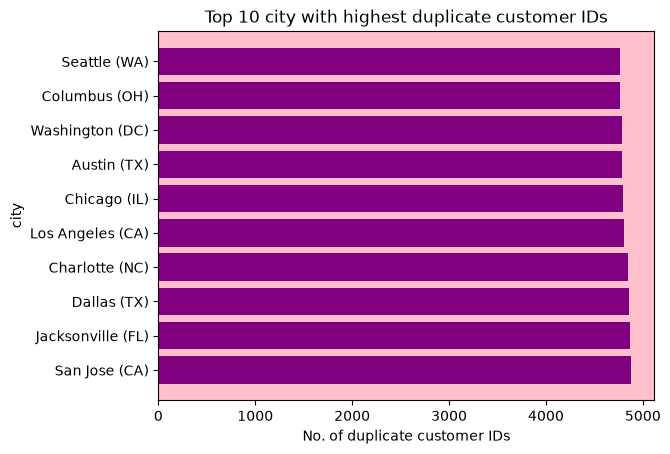

In [79]:
top_10_city = city_duplicates.sort_values(by='DuplicateCount', ascending=False).head(10)
top_10_city['city_label'] = (top_10_city["City"] + " (" + top_10_city["State"] + ")")
plt.barh(top_10_city['city_label'], top_10_city['DuplicateCount'], color='purple')
plt.title('Top 10 city with highest duplicate customer IDs')
plt.ylabel('city')
plt.xlabel('No. of duplicate customer IDs')
ax = plt.gca()
ax.set_facecolor('pink')
plt.show()

##### This horizontal bar graph shows the number of duplicate Customer IDs across different cities, highlighting the city with the maximum duplicates.


## City with order quantity

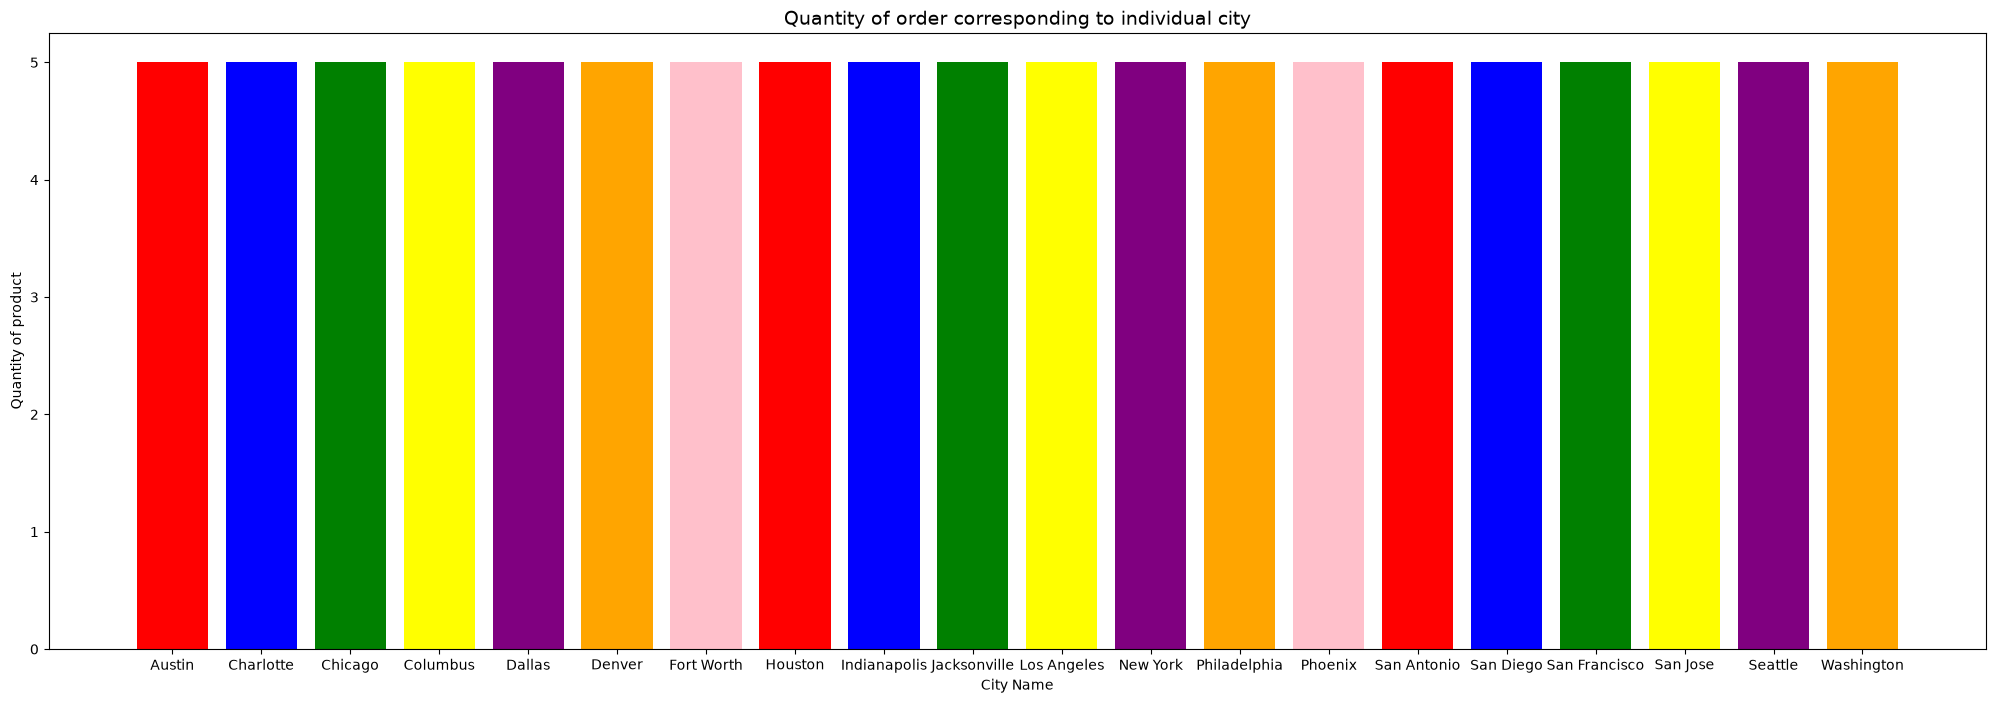

In [104]:
colors = ["red", "blue", "green", "yellow", "purple", "orange", "pink"]
city_name = df.groupby('City')['Quantity'].nunique()
plt.figure(figsize=(25,8))
plt.bar(city_name.index, city_name.values, color=colors)
plt.title('Quantity of order corresponding to individual city', fontsize=14)
plt.xlabel('City Name')
plt.ylabel('Quantity of product')
plt.show()



##### Plot shows quantity of product ordered in each city.

### Most ordered Brand

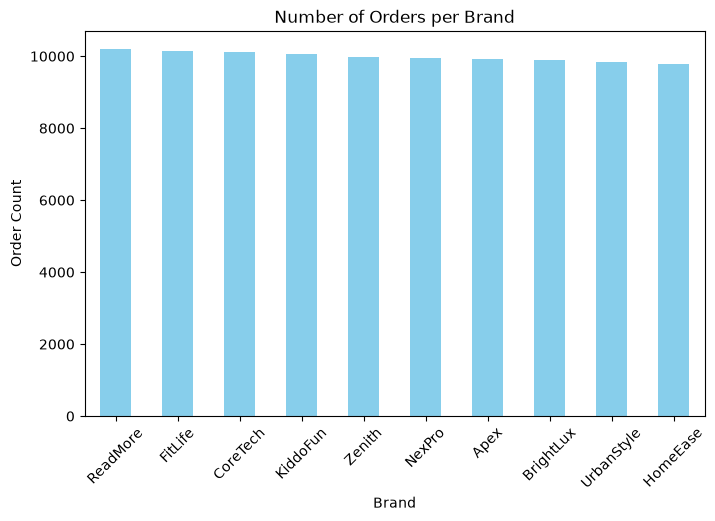

In [107]:

brand_orders = df['Brand'].value_counts()
plt.figure(figsize=(8,5))
brand_orders.plot(kind='bar', color='skyblue')
plt.title('Number of Orders per Brand')
plt.xlabel('Brand')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()


##### From this bar graph we can infer that Readmore brand is more prominent among customer.

## Order status

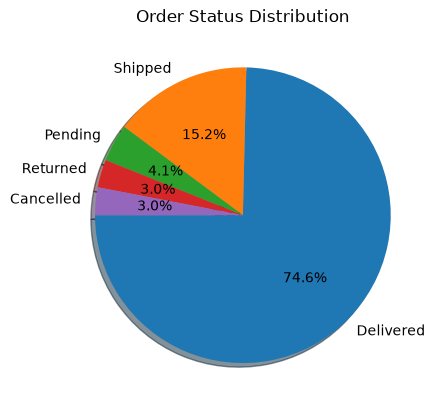

In [117]:
order_status = df['OrderStatus'].value_counts()
order_status.plot(kind='pie',shadow=True,autopct='%1.1f%%',startangle=180)
plt.title('Order Status Distribution')
plt.show()





##### This pie chart depict that most of the product ordered by customer get deliverd and some percentage of the product is shipped, while some are pending. It also shows that the percentage of cancelled and returned product are same.


## Top selling products

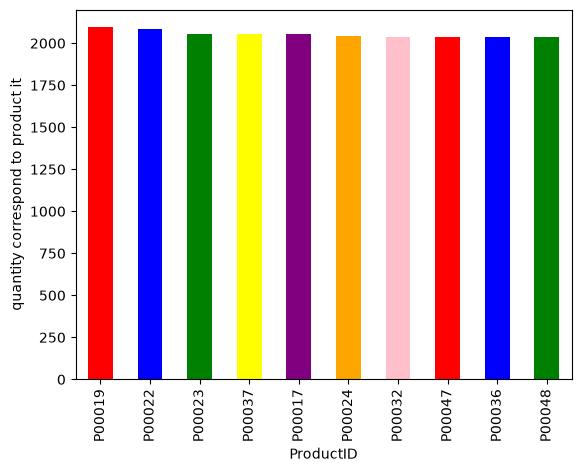

In [121]:

df['ProductID'].value_counts().head(10).plot(kind='bar', color=colors)
plt.ylabel('quantity correspond to product it')
plt.show()

##### From the above bar graph, we can conclude that the product with ProductID P00019 is the most frequently ordered product.

## Category and Order Id

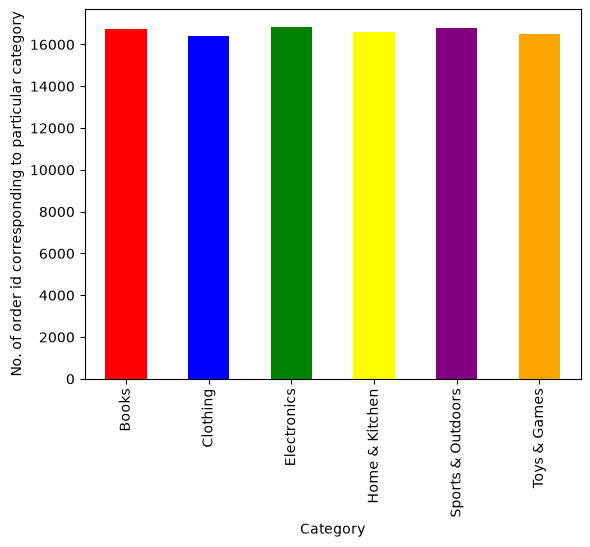

In [122]:
df.groupby('Category')['OrderID'].count().plot(kind='bar',color=colors)
plt.ylabel('No. of order id corresponding to particular category')
plt.show()

##### From the above graph we can infer that category with higher bar is most popular in customer.

## Orders over time

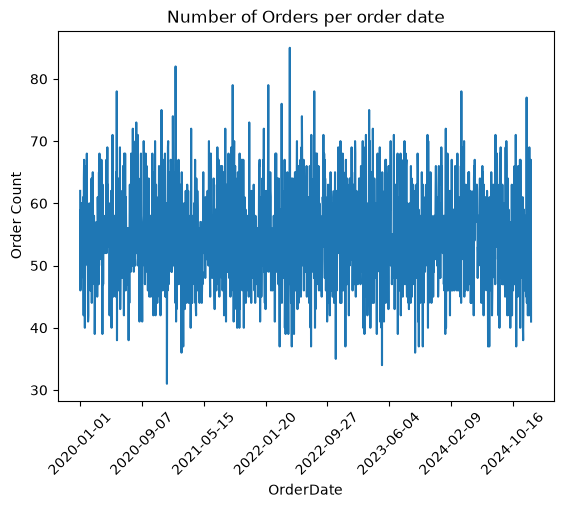

In [125]:

order_time = df.groupby('OrderDate')['OrderID'].count()
order_time.plot(kind='line')
plt.title('Number of Orders per order date')
plt.xlabel('OrderDate')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

##### The line graph illustrates the trend of orders over time. Peaks in the graph indicate dates with high order activity, while troughs represent days with fewer orders.

## Total revenue generation

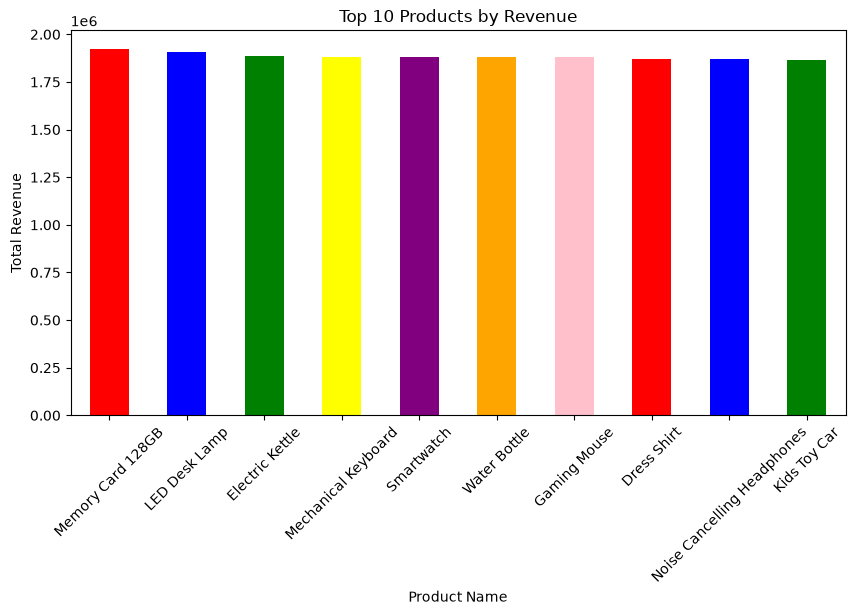

In [129]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Group by product and sum revenue
product_revenue = df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False)
product_revenue.head(10).plot(kind='bar', color=colors, figsize=(10,5))
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()



##### Above graph shows top selling product by revenue. From the above graph, we can infer that memory card is generating high revenue than any other product.

# Summary:

#### With this dataset i come to know and learn many things like;
* How to handle NAN values.
* Different types of plots and which type of plot is suitable for different dataset.
* In this dataset for cleaning, i take the help of Pandas and Numpy labraries. With Numpy and Pandas i    removed useless data and creadted new data frame and series.
* I also use Matplotlib amd Seaborn libraries for visualization of the data.
* This exploratory analysis provide information about sales trends,product performance, customer demographics.In continuation of this analysis, the next step is to design a model that estimates customer purchase amounts across different products.It will enable personalized offers and targeted marketing strategies, thus supporting business goals of improved customer engagement and increased sales.

# References

#### Kaggle: https://www.kaggle.com/datasets/rohiteng/amazon-sales-dataset 